# KAN-DiffCausal: KAN-Based Diffusion with Causal Discovery for Explainable HSI Super-Resolution

## Novel Methodology
- **KAN + Diffusion**: First KAN-based diffusion for HSI super-resolution
- **Causal Discovery**: KAN learns smooth causal relationships between spectral bands
- **Adaptive Rank**: Spatially-adaptive rank prediction using KAN
- **Comprehensive Evaluation**: All KAEXNet metrics (PSNR, SSIM, SAM, RMSE, ERGAS, ASSIM, Faithfulness, Conservation)


## Installing Required Packages


In [37]:
!pip install torch torchvision numpy matplotlib scikit-learn scikit-image tqdm tensorboard pysptools pytorch-msssim

## Imports and Setup


In [38]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from pytorch_msssim import ssim as ssim_fn

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


## FastKAN Convolution Layers


In [39]:
class RadialBasisFunction(nn.Module):
    def __init__(self, grid_min=-2., grid_max=2., num_grids=8, denominator=None):
        super().__init__()
        grid = torch.linspace(grid_min, grid_max, num_grids)
        self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)


class FastKANConvNDLayer(nn.Module):
    def __init__(self, conv_class, norm_class, input_dim, output_dim, kernel_size,
                 groups=1, padding=0, stride=1, dilation=1,
                 ndim: int = 2, grid_size=8, base_activation=nn.SiLU, grid_range=[-2, 2], dropout=0.0, **norm_kwargs):
        super(FastKANConvNDLayer, self).__init__()
        self.inputdim = input_dim
        self.outdim = output_dim
        self.kernel_size = kernel_size
        self.padding = padding
        self.stride = stride
        self.dilation = dilation
        self.groups = groups
        self.ndim = ndim
        self.grid_size = grid_size
        self.base_activation = base_activation()
        self.grid_range = grid_range
        self.norm_kwargs = norm_kwargs

        if groups <= 0:
            raise ValueError('groups must be a positive integer')
        if input_dim % groups != 0:
            raise ValueError('input_dim must be divisible by groups')
        if output_dim % groups != 0:
            raise ValueError('output_dim must be divisible by groups')

        self.base_conv = nn.ModuleList([conv_class(input_dim // groups,
                                                   output_dim // groups,
                                                   kernel_size,
                                                   stride,
                                                   padding,
                                                   dilation,
                                                   groups=1,
                                                   bias=False) for _ in range(groups)])

        self.spline_conv = nn.ModuleList([conv_class(grid_size * input_dim // groups,
                                                     output_dim // groups,
                                                     kernel_size,
                                                     stride,
                                                     padding,
                                                     dilation,
                                                     groups=1,
                                                     bias=False) for _ in range(groups)])

        self.layer_norm = nn.ModuleList([norm_class(input_dim // groups, **norm_kwargs) for _ in range(groups)])
        self.rbf = RadialBasisFunction(grid_range[0], grid_range[1], grid_size)

        self.dropout = None
        if dropout > 0:
            if ndim == 1:
                self.dropout = nn.Dropout1d(p=dropout)
            if ndim == 2:
                self.dropout = nn.Dropout2d(p=dropout)
            if ndim == 3:
                self.dropout = nn.Dropout3d(p=dropout)

        for conv_layer in self.base_conv:
            nn.init.kaiming_uniform_(conv_layer.weight, nonlinearity='linear')
        for conv_layer in self.spline_conv:
            nn.init.kaiming_uniform_(conv_layer.weight, nonlinearity='linear')

    def forward_fast_kan(self, x, group_index):
        base_output = self.base_conv[group_index](self.base_activation(x))
        if self.dropout is not None:
            x = self.dropout(x)
        spline_basis = self.rbf(self.layer_norm[group_index](x))
        spline_basis = spline_basis.moveaxis(-1, 2).flatten(1, 2)
        spline_output = self.spline_conv[group_index](spline_basis)
        x = base_output + spline_output
        return x

    def forward(self, x):
        split_x = torch.split(x, self.inputdim // self.groups, dim=1)
        output = []
        for group_ind, _x in enumerate(split_x):
            y = self.forward_fast_kan(_x, group_ind)
            output.append(y.clone())
        y = torch.cat(output, dim=1)
        return y


class FastKANConv2DLayer(FastKANConvNDLayer):
    def __init__(self, input_dim, output_dim, kernel_size, groups=1, padding=0, stride=1, dilation=1,
                 grid_size=8, base_activation=nn.SiLU, grid_range=[-2, 2], dropout=0.0,
                 norm_layer=nn.InstanceNorm2d, **norm_kwargs):
        super(FastKANConv2DLayer, self).__init__(nn.Conv2d, norm_layer,
                                                 input_dim, output_dim,
                                                 kernel_size,
                                                 groups=groups, padding=padding, stride=stride, dilation=dilation,
                                                 ndim=2,
                                                 grid_size=grid_size, base_activation=base_activation,
                                                 grid_range=grid_range,
                                                 dropout=dropout, **norm_kwargs)


class FastKANConv1DLayer(FastKANConvNDLayer):
    def __init__(self, input_dim, output_dim, kernel_size, groups=1, padding=0, stride=1, dilation=1,
                 grid_size=8, base_activation=nn.SiLU, grid_range=[-2, 2], dropout=0.0,
                 norm_layer=nn.InstanceNorm1d, **norm_kwargs):
        super(FastKANConv1DLayer, self).__init__(nn.Conv1d, norm_layer,
                                                 input_dim, output_dim,
                                                 kernel_size,
                                                 groups=groups, padding=padding, stride=stride, dilation=dilation,
                                                 ndim=1,
                                                 grid_size=grid_size, base_activation=base_activation,
                                                 grid_range=grid_range,
                                                 dropout=dropout, **norm_kwargs)

print("FastKAN layers loaded successfully!")

FastKAN layers loaded successfully!


## KAN-Based Diffusion Denoiser


In [40]:
import math

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class KANDiffusionDenoiser(nn.Module):
    def __init__(self, in_channels, latent_rank=32, time_dim=256, grid_size=8):
        super().__init__()
        self.in_channels = in_channels
        self.latent_rank = latent_rank
        self.time_dim = time_dim

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        # Use regular conv for encoder/decoder — KAN for spatial refinement only
        self.spectral_encoder = nn.Conv2d(in_channels, latent_rank, kernel_size=1, bias=True)
        self.spectral_decoder = nn.Conv2d(latent_rank, in_channels, kernel_size=1, bias=True)

        # Initialize decoder to near-zero so residual starts as identity
        nn.init.zeros_(self.spectral_decoder.weight)
        nn.init.zeros_(self.spectral_decoder.bias)

        self.spatial_refine = nn.ModuleList([
            FastKANConv2DLayer(
                input_dim=latent_rank * 2 if i == 0 else latent_rank,
                output_dim=latent_rank,
                kernel_size=3, padding=1, stride=1,
                grid_size=grid_size, grid_range=[-2, 2], dropout=0.0
            ) for i in range(3)
        ])

        self.time_projs = nn.ModuleList([
            nn.Linear(time_dim, latent_rank) for _ in range(3)
        ])

        self.norm = nn.GroupNorm(8, latent_rank)
        self.act = nn.SiLU()

    def forward(self, x_t, t):
        B, C, H, W = x_t.shape

        time_emb = self.time_mlp(t)

        # Encode: 103 -> latent_rank, no ReLU killing activations
        latent = self.spectral_encoder(x_t)
        latent = self.norm(latent)
        latent = self.act(latent)

        for i, spatial_layer in enumerate(self.spatial_refine):
            time_feat = self.time_projs[i](time_emb).view(B, self.latent_rank, 1, 1)
            if i == 0:
                latent_with_time = torch.cat([latent, time_feat.expand(-1, -1, H, W)], dim=1)
                latent = spatial_layer(latent_with_time)
            else:
                latent = spatial_layer(latent + time_feat)
            latent = self.act(latent)

        # Decode: latent_rank -> 103, initialized to zero = starts as identity residual
        out = self.spectral_decoder(latent)
        return out


class DiffusionScheduler:
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02):
        self.num_timesteps = num_timesteps

        betas = torch.linspace(beta_start, beta_end, num_timesteps)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.register_buffers = {
            'betas': betas,
            'alphas': alphas,
            'alphas_cumprod': alphas_cumprod,
            'alphas_cumprod_prev': alphas_cumprod_prev,
            'sqrt_alphas_cumprod': torch.sqrt(alphas_cumprod),
            'sqrt_one_minus_alphas_cumprod': torch.sqrt(1.0 - alphas_cumprod),
            'posterior_variance': betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod),
        }
        for k, v in self.register_buffers.items():
            setattr(self, k, v)

    def to(self, device):
        for k, v in self.register_buffers.items():
            setattr(self, k, v.to(device))
        return self

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        device = x_start.device
        self.to(device)
        sqrt_ac = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_oneminus_ac = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_ac * x_start + sqrt_oneminus_ac * noise

    def p_losses(self, denoise_model, x_start, t):
        noise = torch.randn_like(x_start)
        x_noisy = self.q_sample(x_start, t, noise)
        predicted_noise = denoise_model(x_noisy, t)
        return F.mse_loss(predicted_noise, noise)

    @torch.no_grad()
    def p_sample(self, denoise_model, x_t, t):
        device = x_t.device
        self.to(device)
        predicted_noise = denoise_model(x_t, t)

        sqrt_ac = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_oneminus_ac = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        x_0_pred = (x_t - sqrt_oneminus_ac * predicted_noise) / sqrt_ac
        x_0_pred = torch.clamp(x_0_pred, 0.0, 1.0)

        betas_t = self.betas[t].view(-1, 1, 1, 1)
        sqrt_recip_alphas_t = torch.sqrt(1.0 / self.alphas[t]).view(-1, 1, 1, 1)

        model_mean = sqrt_recip_alphas_t * (
            x_t - betas_t * predicted_noise / sqrt_oneminus_ac
        )

        if t[0] > 0:
            noise = torch.randn_like(x_t)
            posterior_variance_t = self.posterior_variance[t].view(-1, 1, 1, 1)
            model_mean += torch.sqrt(posterior_variance_t) * noise

        return model_mean

print("Diffusion denoiser loaded successfully!")

Diffusion denoiser loaded successfully!


## KAN-Based Causal Graph for Explainability


In [41]:
class KANCausalGraph(nn.Module):
    """KAN-based causal graph for learning smooth causal relationships"""
    def __init__(self, num_bands, hidden_dim=64, grid_size=8):
        super().__init__()
        self.num_bands = num_bands
        self.hidden_dim = hidden_dim

        self.band_embeddings = nn.Parameter(torch.randn(num_bands, hidden_dim))

        self.causal_kan = FastKANConv1DLayer(
            input_dim=num_bands,
            output_dim=num_bands,
            kernel_size=1,
            padding=0,
            stride=1,
            grid_size=grid_size,
            grid_range=[-2, 2],
            dropout=0.0
        )

        self.causal_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=4,
            batch_first=True
        )

        self.edge_predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, spectra):
        B, C, H, W = spectra.shape
        spectra_flat = spectra.view(B, C, H * W)

        causal_effects = self.causal_kan(spectra_flat)
        causal_matrix = torch.mean(causal_effects, dim=2)  # (B, C)
        band_importance = torch.mean(torch.abs(causal_matrix), dim=0)  # (C,) — one score PER BAND

        return causal_matrix, band_importance

    def compute_causal_loss(self, causal_matrix):
        sparsity_loss = torch.mean(torch.abs(causal_matrix))
        # (B, C) -> (B, C, 1) @ (B, 1, C) = (B, C, C)
        causal_2d = causal_matrix.unsqueeze(2) * causal_matrix.unsqueeze(1)  # element-wise outer product
        acyclicity_loss = torch.mean(torch.abs(causal_2d))
        return sparsity_loss + 0.1 * acyclicity_loss


class CausalFaithfulness(nn.Module):
    """Computes faithfulness score based on causal interventions"""
    def __init__(self, num_bands):
        super().__init__()
        self.num_bands = num_bands

    def compute_faithfulness(self, model, x, top_k_bands, device='cpu'):
        model.eval()

        with torch.no_grad():
            base_output = model(x)

        x_perturbed = x.clone()
        for band_idx in top_k_bands:
            x_perturbed[:, band_idx, :, :] = 0.0

        with torch.no_grad():
            perturbed_output = model(x_perturbed)

        error_base = torch.mean((base_output - x) ** 2)
        error_perturbed = torch.mean((perturbed_output - x) ** 2)

        faithfulness = (error_perturbed - error_base) / (error_base + 1e-8)
        return faithfulness.item()


class ConservationScore(nn.Module):
    """Computes conservation score using integrated gradients"""
    def __init__(self, num_steps=50):
        super().__init__()
        self.num_steps = num_steps

    def compute_conservation(self, model, x, device='cpu'):
        model.eval()

        baseline = torch.zeros_like(x)

        with torch.no_grad():
            output_baseline = model(baseline)
            output_x = model(x)

        output_diff = (output_x - output_baseline).sum()
        input_sum = x.sum()

        conservation = output_diff / (input_sum + 1e-8)
        return conservation.item()

print("Causal graph modules loaded successfully!")

Causal graph modules loaded successfully!


## KAN-Based Adaptive Rank Module


In [42]:
class KANAdaptiveRank(nn.Module):
    def __init__(self, in_channels, max_rank=64, min_rank=16, grid_size=8):
        super().__init__()
        self.in_channels = in_channels
        self.max_rank = max_rank
        self.min_rank = min_rank

        self.context_encoder = FastKANConv2DLayer(
            input_dim=in_channels, output_dim=32,
            kernel_size=3, padding=1, stride=1,
            grid_size=grid_size, grid_range=[-2, 2], dropout=0.0
        )
        self.rank_predictor = FastKANConv2DLayer(
            input_dim=32, output_dim=1,
            kernel_size=3, padding=1, stride=1,
            grid_size=grid_size, grid_range=[-2, 2], dropout=0.0
        )
        self.material_embedding = nn.Embedding(10, 32)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, material_labels=None):
        context = self.context_encoder(x)
        context = self.relu(context)
        if material_labels is not None:
            material_emb = self.material_embedding(material_labels).permute(0, 3, 1, 2)
            context = context + material_emb
        rank_logit = self.rank_predictor(context)
        rank_map = self.sigmoid(rank_logit)
        rank_map = self.min_rank + rank_map * (self.max_rank - self.min_rank)
        return rank_map

    def get_rank(self, x, material_labels=None):
        return self.forward(x, material_labels).mean()


class DynamicSpectralProjection(nn.Module):
    def __init__(self, in_channels, max_rank=64, grid_size=8):
        super().__init__()
        self.in_channels = in_channels
        self.max_rank = max_rank
        self.max_projection = FastKANConv1DLayer(
            input_dim=in_channels, output_dim=max_rank,
            kernel_size=1, padding=0, stride=1,
            grid_size=grid_size, grid_range=[-2, 2], dropout=0.0
        )
        self.expand_back = nn.Conv1d(max_rank, in_channels, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, rank):
        B, C, H, W = x.shape
        x_flat = x.view(B, C, H * W)
        max_projected = self.max_projection(x_flat)
        max_projected = self.relu(max_projected)

        if isinstance(rank, torch.Tensor):
            rank = int(rank.float().mean().item())
        rank = max(1, min(int(rank), self.max_rank))

        # Zero out channels beyond `rank` (instead of slicing) so expand_back
        # always receives a fixed-size (max_rank) input
        mask = torch.zeros_like(max_projected)
        mask[:, :rank, :] = 1.0
        projected = max_projected * mask

        # Project back up to in_channels so this can replace x_lr downstream
        recon = self.expand_back(projected)      # (B, in_channels, H*W)
        recon = recon.view(B, self.in_channels, H, W)
        return recon


class RankRegularization(nn.Module):
    def __init__(self, target_rank=32, weight=0.01):
        super().__init__()
        self.target_rank = target_rank
        self.weight = weight

    def forward(self, rank_map):
        rank_mean = rank_map.mean()
        target = torch.tensor(float(self.target_rank), device=rank_map.device)
        rank_loss = F.mse_loss(rank_mean, target)
        sparsity_loss = rank_map.mean()
        return self.weight * (rank_loss + 0.1 * sparsity_loss)

print("Adaptive rank modules loaded successfully!")

Adaptive rank modules loaded successfully!


## KAN-Based Spectral Unmixing


In [43]:
class KANSpectralUnmixer(nn.Module):
    """KAN-based spectral unmixing for abundance estimation"""
    def __init__(self, num_bands, num_endmembers, grid_size=8):
        super().__init__()
        self.num_bands = num_bands
        self.num_endmembers = num_endmembers
        
        self.unmixer = FastKANConv1DLayer(
            input_dim=num_bands,
            output_dim=num_endmembers,
            kernel_size=1,
            padding=0,
            stride=1,
            grid_size=grid_size,
            grid_range=[-2, 2],
            dropout=0.0
        )
        
        self.endmembers = nn.Parameter(torch.randn(num_endmembers, num_bands))
        nn.init.uniform_(self.endmembers, 0.0, 1.0)
        self.softmax = nn.Softmax(dim=-1)
        
    def forward(self, x):
        B, C, H, W = x.shape
        
        x_flat = x.view(B, C, H * W)
        abundance_flat = self.unmixer(x_flat)
        abundance_flat = self.softmax(abundance_flat)
        abundance = abundance_flat.view(B, self.num_endmembers, H, W)
        
        return abundance, self.endmembers
    
    def get_abundances(self, x):
        abundance, _ = self.forward(x)
        return abundance

print("Spectral unmixer loaded successfully!")

Spectral unmixer loaded successfully!


In [44]:
from pytorch_msssim import ssim as ssim_fn

# ── Learnable upsample block (replaces fixed bilinear) ──────────────────────
class LearnableUpsample(nn.Module):
    """Sub-pixel convolution upsample — learns HOW to upscale, not fixed."""
    def __init__(self, in_channels, scale_factor=2):
        super().__init__()
        self.scale_factor = scale_factor
        # expand channels then shuffle into spatial resolution
        # 103 channels → 103 * 4 = 412 channels for 2× upsampling
        self.conv1 = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2),
                               kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)   # C*r² → C, H*r, W*r
        self.act = nn.SiLU()
        # refine after shuffle
        self.conv2 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pixel_shuffle(x)
        x = self.act(x)
        x = self.conv2(x)
        return x


class KANDiffCausal(nn.Module):
    """
    Complete KAN-DiffCausal Model
    Pipeline: LR → Adaptive Rank → Spectral Projection → PixelShuffle → Diffusion → Causal → Unmixing → SR
    """
    def __init__(self, in_channels, latent_rank=32, num_endmembers=9,
                 num_timesteps=100, max_rank=64, min_rank=16, grid_size=8):
        super().__init__()
        self.in_channels = in_channels
        self.latent_rank = latent_rank
        self.num_endmembers = num_endmembers
        self.num_timesteps = num_timesteps

        self.scheduler = DiffusionScheduler(num_timesteps=num_timesteps)

        # Adaptive rank prediction
        self.adaptive_rank = KANAdaptiveRank(
            in_channels=in_channels,
            max_rank=max_rank,
            min_rank=min_rank,
            grid_size=grid_size
        )

        # Dynamic spectral projection (compresses 103 → adaptive rank)
        self.dynamic_projection = DynamicSpectralProjection(
            in_channels=in_channels,
            max_rank=max_rank,
            grid_size=grid_size
        )

        # Learnable upsampling using PixelShuffle (replaces bilinear)
        self.upsample = LearnableUpsample(in_channels=in_channels, scale_factor=2)

        # KAN-based diffusion denoiser (residual learning)
        self.diffusion_denoiser = KANDiffusionDenoiser(
            in_channels=in_channels,
            latent_rank=latent_rank,
            grid_size=grid_size
        )

        # KAN-based causal graph
        self.causal_graph = KANCausalGraph(
            num_bands=in_channels,
            hidden_dim=64,
            grid_size=grid_size
        )

        # KAN-based spectral unmixer
        self.spectral_unmixer = KANSpectralUnmixer(
            num_bands=in_channels,
            num_endmembers=num_endmembers,
            grid_size=grid_size
        )

        # Faithfulness and conservation modules
        self.faithfulness = CausalFaithfulness(num_bands=in_channels)
        self.conservation = ConservationScore()

        # Rank regularization
        self.rank_regularization = RankRegularization(target_rank=latent_rank)

    def forward(self, x_lr, t=None, material_labels=None):
        """
        Forward pass following user's pipeline:
        1. Adaptive Rank Prediction
        2. Spectral Projection (compress 103 → adaptive rank, then back to 103)
        3. PixelShuffle Upsampling (32×32×103 → 64×64×103)
        4. Diffusion Denoiser (residual correction)
        5. Causal Graph Analysis
        6. Spectral Unmixing
    
        Args:
            x_lr: (B, C, H, W) low-resolution input (32×32×103)
            t: optional timestep for diffusion training
            material_labels: optional (B, H, W) material class labels
        Returns:
            x_sr: (B, C, 2H, 2W) super-resolved output (64×64×103)
            abundance: (B, K, 2H, 2W) abundance maps
            causal_matrix: (B, C) causal relationships
            rank_map: (B, 1, H, W) adaptive rank
        """
        # Step 1: Predict adaptive rank
        rank_map = self.adaptive_rank(x_lr, material_labels)
        avg_rank = rank_map.mean().int()
    
        # Step 2: Dynamic spectral projection (compress 103 → adaptive rank → back to 103)
        # NOTE: this now returns a rank-reduced RECONSTRUCTION of x_lr, same shape as x_lr,
        # so it can actually replace the raw input below. See DynamicSpectralProjection fix.
        latent = self.dynamic_projection(x_lr, avg_rank)
    
        # Step 3: Learnable upsampling using PixelShuffle — now upsamples the rank-reduced
        # signal instead of the raw LR input, so adaptive rank actually affects the output
        x_up = self.upsample(latent)
    
        # Step 4: Diffusion denoising with residual learning
        if t is not None:
            # Training mode: use provided timestep
            denoiser_output = self.diffusion_denoiser(x_up, t)
            # Residual learning: xSR = denoiser_output + xup
            x_sr = denoiser_output + x_up
        else:
            # Inference mode: use t=0 for minimal denoising
            denoiser_output = self.diffusion_denoiser(x_up, torch.zeros(x_up.shape[0], dtype=torch.long, device=x_up.device))
            x_sr = denoiser_output + x_up
    
        # Step 5: Causal graph analysis
        causal_matrix, band_importance = self.causal_graph(x_sr)
    
        # Step 6: Spectral unmixing
        abundance, endmembers = self.spectral_unmixer(x_sr)
    
        return x_sr, abundance, causal_matrix, rank_map
    
    def compute_loss(self, x_lr, x_hr, material_labels=None, lambda_dict=None):
        """
        Compute comprehensive loss including SSIM + faithfulness-alignment
        """
        if lambda_dict is None:
            lambda_dict = {
                'recon': 100.0,
                'ssim': 2.0,
                'sam': 1.0,
                'assim': 0.05,
                'causal': 0.01,   
                'rank': 0.001,
                'diffusion': 1.0
            }
    
        # Forward pass
        t = torch.randint(0, self.num_timesteps, (x_lr.shape[0],), device=x_lr.device)
        x_sr, abundance, causal_matrix, rank_map = self.forward(x_lr, t, material_labels)
    
        losses = {}
    
        # Reconstruction loss (L1)
        losses['recon'] = F.l1_loss(x_sr, x_hr)
    
        # SSIM loss
        losses['ssim'] = 1.0 - ssim_fn(x_sr, x_hr, data_range=1.0)
    
        # SAM loss
        losses['sam'] = self.compute_sam_loss(x_sr, x_hr)
    
        # ASSIM loss (abundance consistency)
        losses['assim'] = torch.mean(torch.abs(abundance))
    
        # Causal loss (sparsity + acyclicity)
        losses['causal'] = self.causal_graph.compute_causal_loss(causal_matrix)
    
    
        # Rank regularization
        losses['rank'] = self.rank_regularization(rank_map)
    
        # Diffusion loss (compute on upsampled image)
        x_up = self.upsample(x_lr)
        diffusion_loss = self.scheduler.p_losses(self.diffusion_denoiser, x_up, t)
        losses['diffusion'] = diffusion_loss
    
        # Total loss
        total_loss = (
            lambda_dict['recon'] * losses['recon'] +
            lambda_dict['ssim'] * losses['ssim'] +
            lambda_dict['sam'] * losses['sam'] +
            lambda_dict['assim'] * losses['assim'] +
            lambda_dict['causal'] * losses['causal'] +
            lambda_dict['rank'] * losses['rank'] +
            lambda_dict['diffusion'] * losses['diffusion']
        )
    
        losses['total'] = total_loss
    
        return losses
    
    def compute_sam_loss(self, pred, gt, eps=1e-8):
        """Compute SAM loss"""
        pred_flat = pred.view(pred.shape[0], pred.shape[1], -1)
        gt_flat = gt.view(gt.shape[0], gt.shape[1], -1)
        
        dot = (pred_flat * gt_flat).sum(dim=1)
        norm_pred = torch.norm(pred_flat, dim=1)
        norm_gt = torch.norm(gt_flat, dim=1)
        
        cos = dot / (norm_pred * norm_gt + eps)
        cos = torch.clamp(cos, -1.0, 1.0)
        
        sam = torch.acos(cos) * (180.0 / torch.pi)
        return sam.mean()
    
    def get_explainability(self, x_lr, material_labels=None):
        """
        Get explainability information
        """
        with torch.no_grad():
            x_sr, abundance, causal_matrix, rank_map = self.forward(x_lr, material_labels=material_labels)
            
            explainability = {
                'band_importance': torch.mean(torch.abs(causal_matrix), dim=0),
                'causal_matrix': causal_matrix,
                'abundance_maps': abundance,
                'rank_map': rank_map,
                'endmembers': self.spectral_unmixer.endmembers
            }
            
        return explainability

print("KAN-DiffCausal model loaded successfully!")

KAN-DiffCausal model loaded successfully!


## Comprehensive Evaluation Metrics


In [45]:
class ComprehensiveMetrics:
    """Comprehensive evaluation metrics for hyperspectral super-resolution"""
    
    @staticmethod
    def compute_psnr(pred, gt):
        if isinstance(pred, torch.Tensor):
            pred = pred.cpu().numpy()
        if isinstance(gt, torch.Tensor):
            gt = gt.cpu().numpy()
        
        if pred.ndim == 4:
            psnr_values = []
            for b in range(pred.shape[0]):
                pred_b = pred[b].transpose(1, 2, 0)
                gt_b = gt[b].transpose(1, 2, 0)
                data_range = gt_b.max() - gt_b.min()
                psnr_b = psnr(gt_b, pred_b, data_range=data_range)
                psnr_values.append(psnr_b)
            return np.mean(psnr_values)
        else:
            data_range = gt.max() - gt.min()
            return psnr(gt, pred, data_range=data_range)
    
    @staticmethod
    def compute_ssim(pred, gt):
        if isinstance(pred, torch.Tensor):
            pred = pred.cpu().numpy()
        if isinstance(gt, torch.Tensor):
            gt = gt.cpu().numpy()
        
        if pred.ndim == 4:
            ssim_values = []
            for b in range(pred.shape[0]):
                pred_b = pred[b].transpose(1, 2, 0)
                gt_b = gt[b].transpose(1, 2, 0)
                data_range = gt_b.max() - gt_b.min()
                ssim_b = ssim(gt_b, pred_b, channel_axis=-1, data_range=data_range)
                ssim_values.append(ssim_b)
            return np.mean(ssim_values)
        else:
            data_range = gt.max() - gt.min()
            return ssim(gt, pred, channel_axis=-1, data_range=data_range)
    
    @staticmethod
    def compute_sam(pred, gt, eps=1e-8):
        if isinstance(pred, torch.Tensor):
            pred = pred.cpu().numpy()
        if isinstance(gt, torch.Tensor):
            gt = gt.cpu().numpy()
        
        if pred.ndim == 4:
            sam_values = []
            for b in range(pred.shape[0]):
                pred_b = pred[b].transpose(1, 2, 0)
                gt_b = gt[b].transpose(1, 2, 0)
                
                H, W, C = pred_b.shape
                pred_flat = pred_b.reshape(-1, C)
                gt_flat = gt_b.reshape(-1, C)
                
                dot = np.sum(pred_flat * gt_flat, axis=1)
                norm_pred = np.linalg.norm(pred_flat, axis=1)
                norm_gt = np.linalg.norm(gt_flat, axis=1)
                
                cos_sim = dot / (norm_pred * norm_gt + eps)
                cos_sim = np.clip(cos_sim, -1.0, 1.0)
                
                angles = np.arccos(cos_sim) * (180.0 / np.pi)
                sam_values.append(np.mean(angles))
            
            return np.mean(sam_values)
        else:
            H, W, C = pred.shape
            pred_flat = pred.reshape(-1, C)
            gt_flat = gt.reshape(-1, C)
            
            dot = np.sum(pred_flat * gt_flat, axis=1)
            norm_pred = np.linalg.norm(pred_flat, axis=1)
            norm_gt = np.linalg.norm(gt_flat, axis=1)
            
            cos_sim = dot / (norm_pred * norm_gt + eps)
            cos_sim = np.clip(cos_sim, -1.0, 1.0)
            
            angles = np.arccos(cos_sim) * (180.0 / np.pi)
            return np.mean(angles)
    
    @staticmethod
    def compute_rmse(pred, gt):
        if isinstance(pred, torch.Tensor):
            pred = pred.cpu().numpy()
        if isinstance(gt, torch.Tensor):
            gt = gt.cpu().numpy()
        return np.sqrt(np.mean((pred - gt) ** 2))
    
    @staticmethod
    def compute_ergas(pred, gt, scale):
        if isinstance(pred, torch.Tensor):
            pred = pred.cpu().numpy()
        if isinstance(gt, torch.Tensor):
            gt = gt.cpu().numpy()
        
        if pred.ndim == 4:
            ergas_values = []
            for b in range(pred.shape[0]):
                pred_b = pred[b].transpose(1, 2, 0)
                gt_b = gt[b].transpose(1, 2, 0)
                
                C = pred_b.shape[-1]
                ergas_sum = 0.0
                
                for c in range(C):
                    rmse_c = np.sqrt(np.mean((pred_b[:, :, c] - gt_b[:, :, c]) ** 2))
                    mean_c = np.mean(gt_b[:, :, c])
                    
                    if mean_c > 1e-8:
                        ergas_sum += (rmse_c / mean_c) ** 2
                
                ergas = (100.0 / scale) * np.sqrt(ergas_sum / C)
                ergas_values.append(ergas)
            
            return np.mean(ergas_values)
        else:
            C = pred.shape[-1]
            ergas_sum = 0.0
            
            for c in range(C):
                rmse_c = np.sqrt(np.mean((pred[:, :, c] - gt[:, :, c]) ** 2))
                mean_c = np.mean(gt[:, :, c])
                
                if mean_c > 1e-8:
                    ergas_sum += (rmse_c / mean_c) ** 2
            
            ergas = (100.0 / scale) * np.sqrt(ergas_sum / C)
            return ergas
    
    @staticmethod
    def compute_assim(abundance_pred, abundance_gt):
        if isinstance(abundance_pred, torch.Tensor):
            abundance_pred = abundance_pred.cpu().numpy()
        if isinstance(abundance_gt, torch.Tensor):
            abundance_gt = abundance_gt.cpu().numpy()
        
        if abundance_pred.ndim == 4:
            N = abundance_pred.shape[0]
            K = abundance_pred.shape[-1]
            
            assim_values = []
            for b in range(N):
                pred_b = abundance_pred[b]
                gt_b = abundance_gt[b]
                
                mu_pred = pred_b.mean(axis=(0, 1))
                mu_gt = gt_b.mean(axis=(0, 1))
                
                var_pred = pred_b.var(axis=(0, 1))
                var_gt = gt_b.var(axis=(0, 1))
                
                cov = ((pred_b - mu_pred) * (gt_b - mu_gt)).mean(axis=(0, 1))
                
                numerator = 2 * mu_pred * mu_gt * cov
                denominator = (mu_pred ** 2 + mu_gt ** 2) * (var_pred + var_gt)
                assim_b = (numerator / (denominator + 1e-8)).mean()
                
                assim_values.append(assim_b)
            
            return np.mean(assim_values)
        else:
            K = abundance_pred.shape[-1]
            
            mu_pred = abundance_pred.mean(axis=(0, 1))
            mu_gt = abundance_gt.mean(axis=(0, 1))
            
            var_pred = abundance_pred.var(axis=(0, 1))
            var_gt = abundance_gt.var(axis=(0, 1))
            
            cov = ((abundance_pred - mu_pred) * (abundance_gt - mu_gt)).mean(axis=(0, 1))
            
            numerator = 2 * mu_pred * mu_gt * cov
            denominator = (mu_pred ** 2 + mu_gt ** 2) * (var_pred + var_gt)
            assim = (numerator / (denominator + 1e-8)).mean()
            
            return assim
    
    @staticmethod
    def compute_all_metrics(pred, gt, scale, model=None, x=None, device='cpu'):
        metrics = {}
        
        metrics['PSNR'] = ComprehensiveMetrics.compute_psnr(pred, gt)
        metrics['SSIM'] = ComprehensiveMetrics.compute_ssim(pred, gt)
        metrics['SAM'] = ComprehensiveMetrics.compute_sam(pred, gt)
        metrics['RMSE'] = ComprehensiveMetrics.compute_rmse(pred, gt)
        metrics['ERGAS'] = ComprehensiveMetrics.compute_ergas(pred, gt, scale)
        
        return metrics

print("Comprehensive metrics loaded successfully!")

Comprehensive metrics loaded successfully!


## Dataset Loading for Pavia University


In [46]:
def load_npy_files_from_folder(folder_path):
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".npy")])
    arrs = []
    for f in files:
        a = np.load(os.path.join(folder_path, f))
        if a.ndim == 2:
            a = a[:, :, None]
        arrs.append(a.astype(np.float32))
    return np.stack(arrs, 0)


class HSISuperResolutionDataset(Dataset):
    def __init__(self, lr_images, hr_images, normalize="global", augment=True):
        assert lr_images.shape[0] == hr_images.shape[0]
        self.lr_images = lr_images
        self.hr_images = hr_images
        self.normalize = normalize
        self.augment = augment

        if normalize == "global":
            self.lr_min, self.lr_max = lr_images.min(), lr_images.max()
            self.hr_min, self.hr_max = hr_images.min(), hr_images.max()
            self.lr_images = (lr_images - self.lr_min) / (self.lr_max - self.lr_min + 1e-8)
            self.hr_images = (hr_images - self.hr_min) / (self.hr_max - self.hr_min + 1e-8)

    def __len__(self):
        return self.lr_images.shape[0]

    def __getitem__(self, idx):
        lr_img = self.lr_images[idx].copy()
        hr_img = self.hr_images[idx].copy()

        if self.augment:
            k = np.random.randint(0, 4)
            # FIX: .copy() after rot90 and flip to avoid negative strides
            lr_img = np.rot90(lr_img, k, axes=(0, 1)).copy()
            hr_img = np.rot90(hr_img, k, axes=(0, 1)).copy()
            if np.random.rand() < 0.5:
                lr_img = np.flip(lr_img, axis=1).copy()
                hr_img = np.flip(hr_img, axis=1).copy()
            if np.random.rand() < 0.5:
                lr_img = np.flip(lr_img, axis=0).copy()
                hr_img = np.flip(hr_img, axis=0).copy()

        lr_tensor = torch.from_numpy(lr_img).float().permute(2, 0, 1)
        hr_tensor = torch.from_numpy(hr_img).float().permute(2, 0, 1)
        return lr_tensor, hr_tensor


def create_dataloaders(lr_folder, hr_folder, batch_size=16, test_size=0.2, num_workers=0):
    lr_images = load_npy_files_from_folder(lr_folder)
    hr_images = load_npy_files_from_folder(hr_folder)

    print(f"LR shape: {lr_images.shape}")
    print(f"HR shape: {hr_images.shape}")

    train_lr, test_lr, train_hr, test_hr = train_test_split(
        lr_images, hr_images, test_size=test_size, random_state=42
    )
    print(f"Train: {len(train_lr)} | Test: {len(test_lr)}")

    train_dataset = HSISuperResolutionDataset(train_lr, train_hr, augment=True)
    test_dataset  = HSISuperResolutionDataset(test_lr,  test_hr,  augment=False)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True, drop_last=False)

    return train_loader, test_loader, train_dataset, test_dataset

print("Dataset loading functions loaded successfully!")


Dataset loading functions loaded successfully!


## Configuration for Pavia University Dataset


In [47]:
# ==================== CONFIGURATION ====================
# Update these paths according to your Kaggle dataset structure

# Pavia University dataset paths (update these!)
# Example: /kaggle/input/pavia-university-hsi/LR_X2 and /kaggle/input/pavia-university-hsi/HR_X2
LR_FOLDER = r"/kaggle/input/datasets/venkatasriharika/paviau-patches01/patches_folder/LR"  # Update with your LR folder path
HR_FOLDER = r"/kaggle/input/datasets/venkatasriharika/paviau-patches01/patches_folder/HR"  # Update with your HR folder path

# Model hyperparameters
NUM_BANDS = 103  # Pavia University has 103 spectral bands
NUM_ENDMEMBERS = 9  # Number of endmembers for unmixing
LATENT_RANK = 32  # Latent rank for diffusion
MAX_RANK = 64  # Maximum adaptive rank
MIN_RANK = 16  # Minimum adaptive rank
NUM_TIMESTEPS = 100  # Diffusion timesteps
GRID_SIZE = 8  # KAN grid size

# Training hyperparameters
BATCH_SIZE = 8  # Adjust based on GPU memory
EPOCHS = 100
LEARNING_RATE = 1e-4
SCALE = 2  # Upscaling factor

# Output directory
OUTPUT_DIR = r"./results"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded!")
print(f"LR Folder: {LR_FOLDER}")
print(f"HR Folder: {HR_FOLDER}")
print(f"Number of bands: {NUM_BANDS}")
print(f"Batch size: {BATCH_SIZE}")

Configuration loaded!
LR Folder: /kaggle/input/datasets/venkatasriharika/paviau-patches01/patches_folder/LR
HR Folder: /kaggle/input/datasets/venkatasriharika/paviau-patches01/patches_folder/HR
Number of bands: 103
Batch size: 8


## Loading Dataset and Creating Dataloaders


In [48]:
# Load dataset
print("Loading Pavia University dataset...")
train_loader, test_loader, train_dataset, test_dataset = create_dataloaders(
    LR_FOLDER, HR_FOLDER, 
    batch_size=BATCH_SIZE, 
    test_size=0.2, 
    num_workers=0
)

print("Dataset loaded successfully!")

Loading Pavia University dataset...
LR shape: (2415, 32, 32, 103)
HR shape: (2415, 64, 64, 103)
Train: 1932 | Test: 483
Dataset loaded successfully!


## Initializing the KAN-DiffCausal Model


In [49]:
# Create model
print("Creating KAN-DiffCausal model...")
model = KANDiffCausal(
    in_channels=NUM_BANDS,
    latent_rank=LATENT_RANK,
    num_endmembers=NUM_ENDMEMBERS,
    num_timesteps=NUM_TIMESTEPS,
    max_rank=MAX_RANK,
    min_rank=MIN_RANK,
    grid_size=GRID_SIZE
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# Per-param-group optimizer — spline weights need higher LR
spline_params = [p for n, p in model.named_parameters() if 'spline' in n]
other_params  = [p for n, p in model.named_parameters() if 'spline' not in n]
optimizer = optim.Adam([
    {'params': spline_params, 'lr': 1e-3},
    {'params': other_params,  'lr': 1e-4}
], betas=(0.9, 0.999))

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2, eta_min=1e-7)

# Tensorboard writer
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_dir = os.path.join(OUTPUT_DIR, f'logs_{timestamp}')
ckpt_dir = os.path.join(OUTPUT_DIR, f'checkpoints_{timestamp}')
os.makedirs(log_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)
writer = SummaryWriter(log_dir)

print("Model initialized successfully!")

Creating KAN-DiffCausal model...
Total trainable parameters: 1,444,958
Model initialized successfully!


## Validation Function


In [50]:
def validate(model, test_loader, scale, device):
    model.eval()

    all_preds = []
    all_gts = []
    all_abundances = []      # abundances from SR output (64x64)
    all_gt_abundances = []   # abundances from HR images directly via unmixer (64x64)

    with torch.no_grad():
        for lr_imgs, hr_imgs in tqdm(test_loader, desc="Validation"):
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)

            t = torch.zeros(lr_imgs.shape[0], dtype=torch.long, device=device)
            x_sr, abundance, _, _ = model.forward(lr_imgs, t)

            all_preds.append(x_sr.cpu())
            all_gts.append(hr_imgs.cpu())
            all_abundances.append(abundance.cpu())

            # ── GT abundances: pass HR directly through unmixer ONLY (no upsample) ──
            gt_abundance, _ = model.spectral_unmixer(hr_imgs)
            all_gt_abundances.append(gt_abundance.cpu())

    all_preds         = torch.cat(all_preds, dim=0)
    all_gts           = torch.cat(all_gts, dim=0)
    all_abundances    = torch.cat(all_abundances, dim=0)
    all_gt_abundances = torch.cat(all_gt_abundances, dim=0)

    metrics = ComprehensiveMetrics.compute_all_metrics(
        all_preds, all_gts, scale, device=device
    )

    # ── A-SSIM: both tensors now (B, 9, 64, 64) → permute to (B, 64, 64, 9) ──
    pred_ab_np = all_abundances.permute(0, 2, 3, 1).numpy()
    gt_ab_np   = all_gt_abundances.permute(0, 2, 3, 1).numpy()
    metrics['A-SSIM'] = ComprehensiveMetrics.compute_assim(pred_ab_np, gt_ab_np)

    return metrics

print("Validation function defined!")

Validation function defined!


## Training Loop


In [57]:
# Loss weights
lambda_dict = {
    'recon': 100.0,
    'ssim': 5.0,
    'sam': 0.05,
    'assim': 0.05,
    'causal': 0.01,
    'rank': 0.001,
    'diffusion': 1.0
}

WARMUP_EPOCHS = 5

def get_lr_scale(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    return 1.0

best_psnr = 0.0

print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    epoch_losses = {
        'recon': 0.0,
        'ssim': 0.0,
        'sam': 0.0,
        'assim': 0.0,
        'causal': 0.0,
        'rank': 0.0,
        'diffusion': 0.0,
        'total': 0.0
    }

    # Warmup
    if epoch < WARMUP_EPOCHS:
        lr_scale = get_lr_scale(epoch)
        for pg in optimizer.param_groups:
            pg['lr'] = pg['lr'] * lr_scale

    # Training
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch_idx, (lr_imgs, hr_imgs) in enumerate(pbar):
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)

        optimizer.zero_grad()

        # Compute loss
        losses = model.compute_loss(lr_imgs, hr_imgs, material_labels=None, lambda_dict=lambda_dict)

        # Backward
        losses['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Accumulate losses
        for key in epoch_losses:
            epoch_losses[key] += losses[key].item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f"{losses['total'].item():.4f}",
            'recon': f"{losses['recon'].item():.4f}",
            'sam': f"{losses['sam'].item():.4f}"
        })

    # Average epoch losses
    for key in epoch_losses:
        epoch_losses[key] /= len(train_loader)

    # Log training losses
    for key, value in epoch_losses.items():
        writer.add_scalar(f'train/{key}', value, epoch)

    # Validation
    if (epoch + 1) % 5 == 0:
        print(f"\nValidating at epoch {epoch+1}...")
        val_metrics = validate(model, test_loader, SCALE, device)

        # Log validation metrics
        for key, value in val_metrics.items():
            writer.add_scalar(f'val/{key}', value, epoch)

        print(f"Validation PSNR:   {val_metrics['PSNR']:.4f}")
        print(f"Validation SSIM:   {val_metrics['SSIM']:.4f}")
        print(f"Validation SAM:    {val_metrics['SAM']:.4f}")
        print(f"Epoch A-SSIM:      {val_metrics['A-SSIM']:.16f}")

        # Save best model
        if val_metrics['PSNR'] > best_psnr:
            best_psnr = val_metrics['PSNR']
            checkpoint_path = os.path.join(ckpt_dir, 'best_model.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'psnr': best_psnr,
                'metrics': val_metrics
            }, checkpoint_path)
            print(f"Saved best model with PSNR: {best_psnr:.4f}")

    # Save checkpoint
    if (epoch + 1) % 20 == 0:
        checkpoint_path = os.path.join(ckpt_dir, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': epoch_losses
        }, checkpoint_path)

    # Step scheduler
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_losses['total']:.4f}")

print("Training complete!")
writer.close()

Starting training...


Epoch 1/100: 100%|██████████| 241/241 [00:41<00:00,  5.84it/s, loss=2.3893, recon=0.0097, sam=2.9712]


Epoch 1/100 - Loss: 2.5261


Epoch 2/100: 100%|██████████| 241/241 [00:39<00:00,  6.05it/s, loss=2.6183, recon=0.0116, sam=3.3421]


Epoch 2/100 - Loss: 2.5415


...

Epoch 99/100 - Loss: 2.3748


Epoch 100/100: 100%|██████████| 241/241 [00:40<00:00,  5.99it/s, loss=2.3047, recon=0.0096, sam=3.1386]



Validating at epoch 100...


Validation: 100%|██████████| 61/61 [00:03<00:00, 16.65it/s]


Validation PSNR:   34.0416
Validation SSIM:   0.9480
Validation SAM:    3.1033
Epoch A-SSIM:      0.0000000475432600
Saved best model with PSNR: 34.0416
Epoch 100/100 - Loss: 2.3736
Training complete!


In [70]:
# ==================== XAI METRICS AFTER TRAINING ====================
def compute_xai_metrics(model, test_loader, device, top_k=5, scale=None):
    model.eval()

    xai_scores          = []
    xai_band_scores     = []
    faithfulness_scores = []
    conservation_scores = []
    psnr_scores  = []
    ssim_scores  = []
    sam_scores   = []
    rmse_scores  = []
    ergas_scores = []

    with torch.no_grad():
        for lr_imgs, hr_imgs in tqdm(test_loader, desc="XAI Metrics"):
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)
            B = lr_imgs.shape[0]

            t = torch.zeros(B, dtype=torch.long, device=device)
            x_sr, abundance, causal_matrix, rank_map = model.forward(lr_imgs, t)

            # ── 1. XAI Score: SSIM(SR, GT) ──────────────────────────────────
            ssim_val = ssim_fn(x_sr, hr_imgs, data_range=1.0, size_average=True)
            xai_scores.append(ssim_val.item())

            # ── 2. XAI Band Score: mean signed causal response ───────────────
            band_score = causal_matrix.mean().item()
            xai_band_scores.append(band_score)

            # ── 3. Faithfulness ────────────────────────────────────────────
            band_importance = torch.mean(torch.abs(causal_matrix), dim=0)
            top_k_bands = torch.topk(band_importance, top_k).indices.tolist()

            x_perturbed = lr_imgs.clone()
            for band_idx in top_k_bands:
                x_perturbed[:, band_idx, :, :] = 0.0

            x_sr_base, _, _, _      = model.forward(lr_imgs,    t)
            x_sr_perturbed, _, _, _ = model.forward(x_perturbed, t)

            err_base      = F.mse_loss(x_sr_base,      hr_imgs).item()
            err_perturbed = F.mse_loss(x_sr_perturbed, hr_imgs).item()
            faithfulness  = (err_perturbed - err_base) / (err_base + 1e-8)
            faithfulness_scores.append(faithfulness)

            # ── 4. Conservation ───────────────────────────────────────────
            baseline = torch.zeros_like(lr_imgs)
            x_sr_zero, _, _, _ = model.forward(baseline, t)
            output_diff  = (x_sr - x_sr_zero).sum().item()
            input_sum    = lr_imgs.sum().item()
            conservation = output_diff / (input_sum + 1e-8)
            conservation_scores.append(conservation)

            # ── 5. Comprehensive image-quality metrics (batch-level) ────────
            batch_metrics = ComprehensiveMetrics.compute_all_metrics(
                x_sr, hr_imgs, scale=scale if scale is not None else SCALE
            )
            psnr_scores.append(batch_metrics['PSNR'])
            ssim_scores.append(batch_metrics['SSIM'])
            sam_scores.append(batch_metrics['SAM'])
            rmse_scores.append(batch_metrics['RMSE'])
            ergas_scores.append(batch_metrics['ERGAS'])

    results = {
        'mean_xai':          float(np.mean(xai_scores)),
        'mean_xai_band':     float(np.mean(xai_band_scores)),
        'faithfulness':      float(np.mean(faithfulness_scores)),
        'conservation':      float(np.mean(conservation_scores)),
        'PSNR':              float(np.mean(psnr_scores)),
        'SSIM':              float(np.mean(ssim_scores)),
        'SAM':               float(np.mean(sam_scores)),
        'RMSE':              float(np.mean(rmse_scores)),
        'ERGAS':             float(np.mean(ergas_scores)),
    }

    print(f"Mean XAI Score:          {results['mean_xai']:.4f}")
    print(f"Mean XAI band own Score: {results['mean_xai_band']:.6f}")
    print(f"Faithfulness Mean:       {results['faithfulness']:.4f}")
    print(f"Conservation Mean:       {results['conservation']:.4f}")
    print(f"PSNR:                    {results['PSNR']:.4f} dB")
    print(f"SSIM:                    {results['SSIM']:.4f}")
    print(f"SAM:                     {results['SAM']:.4f} degrees")
    print(f"RMSE:                    {results['RMSE']:.6f}")
    print(f"ERGAS:                   {results['ERGAS']:.4f}")

    return results

print("Computing XAI metrics on test set...")
xai_results = compute_xai_metrics(model, test_loader, device=device, top_k=25, scale=SCALE)

Computing XAI metrics on test set...


XAI Metrics: 100%|██████████| 61/61 [00:30<00:00,  2.00it/s]

Mean XAI Score:          0.9542
Mean XAI band own Score: -0.000216
Faithfulness Mean:       9.1954
Conservation Mean:       3.0109
PSNR:                    34.0415 dB
SSIM:                    0.9479
SAM:                     3.0988 degrees
RMSE:                    0.016390
ERGAS:                   5.2493


## Testing and Visualization


Running test and visualization...


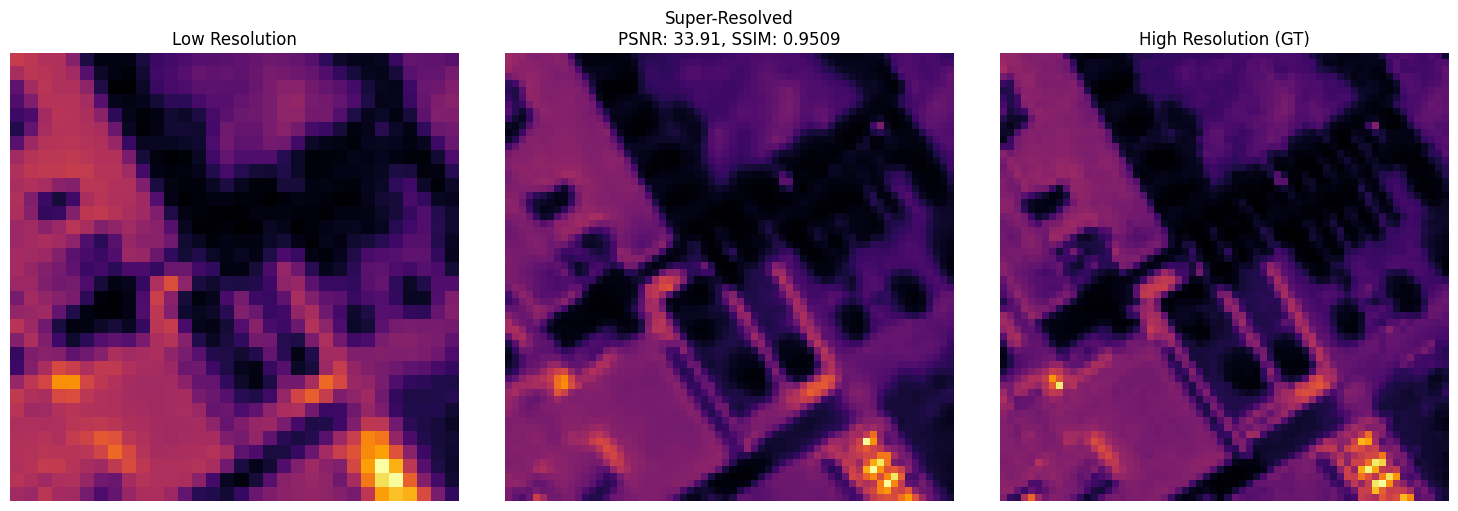

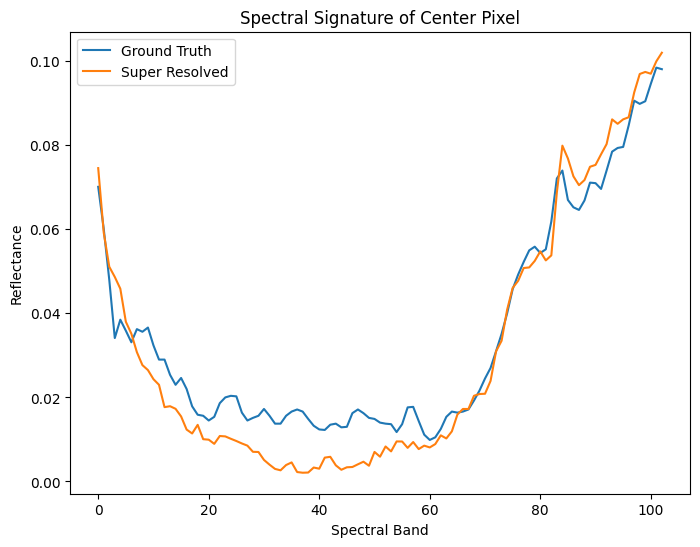

Metrics: {'PSNR': np.float64(33.91457349318747), 'SSIM': np.float32(0.95091116), 'SAM': np.float32(3.2862651), 'RMSE': np.float32(0.017419409), 'ERGAS': np.float32(5.3658466)}


In [71]:
def test_and_visualize(model, test_loader, device='cpu', sample_idx=0, band=50):
    """Test model and visualize results"""
    model.eval()
    
    with torch.no_grad():
        for lr_imgs, hr_imgs in test_loader:
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)
            
            t = torch.zeros(lr_imgs.shape[0], dtype=torch.long, device=device)
            sr_imgs, _, _, _ = model.forward(lr_imgs, t)
            
            lr_np = lr_imgs[sample_idx].cpu().numpy().transpose(1, 2, 0)
            hr_np = hr_imgs[sample_idx].cpu().numpy().transpose(1, 2, 0)
            sr_np = sr_imgs[sample_idx].cpu().numpy().transpose(1, 2, 0)
            
            metrics = ComprehensiveMetrics.compute_all_metrics(sr_imgs, hr_imgs, SCALE, device=device)
            
            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            axs[0].imshow(lr_np[:, :, band], cmap='inferno'); axs[0].set_title("Low Resolution"); axs[0].axis('off')
            axs[1].imshow(sr_np[:, :, band], cmap='inferno'); axs[1].set_title(f"Super-Resolved\nPSNR: {metrics['PSNR']:.2f}, SSIM: {metrics['SSIM']:.4f}"); axs[1].axis('off')
            axs[2].imshow(hr_np[:, :, band], cmap='inferno'); axs[2].set_title("High Resolution (GT)"); axs[2].axis('off')
            plt.tight_layout()
            plt.show()
            
            h, w, num_bands = hr_np.shape
            center_h, center_w = h // 2, w // 2
            plt.figure(figsize=(8, 6))
            plt.plot(range(num_bands), hr_np[center_h, center_w, :], label='Ground Truth')
            plt.plot(range(num_bands), sr_np[center_h, center_w, :], label='Super Resolved')
            plt.xlabel('Spectral Band'); plt.ylabel('Reflectance'); plt.title('Spectral Signature of Center Pixel')
            plt.legend()
            plt.show()
            
            print(f"Metrics: {metrics}")
            break

print("Running test and visualization...")
test_and_visualize(model, test_loader, device=device, sample_idx=0, band=50)

## Explainability Analysis


## Saving Final Results


Analyzing explainability...


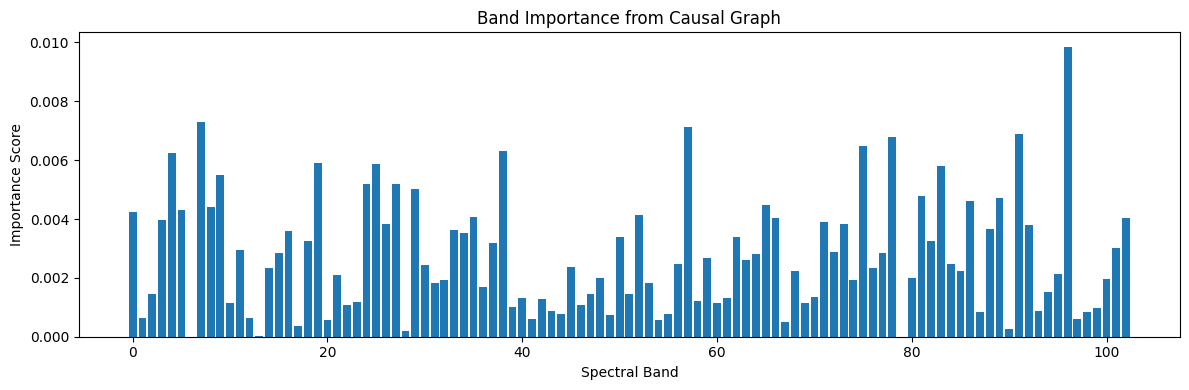

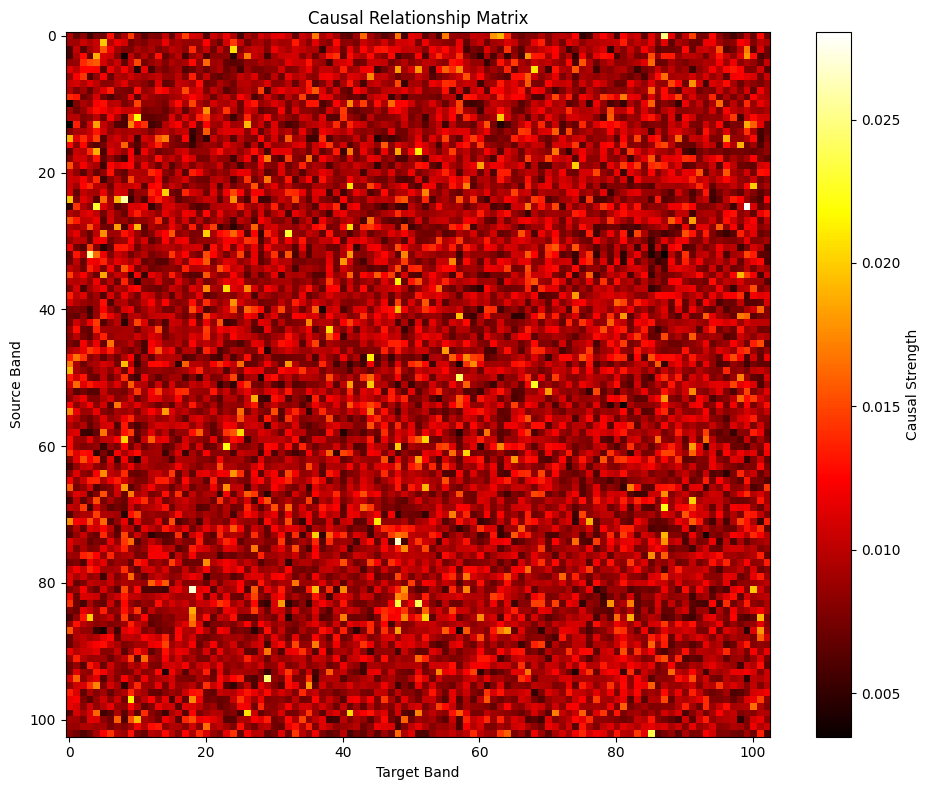

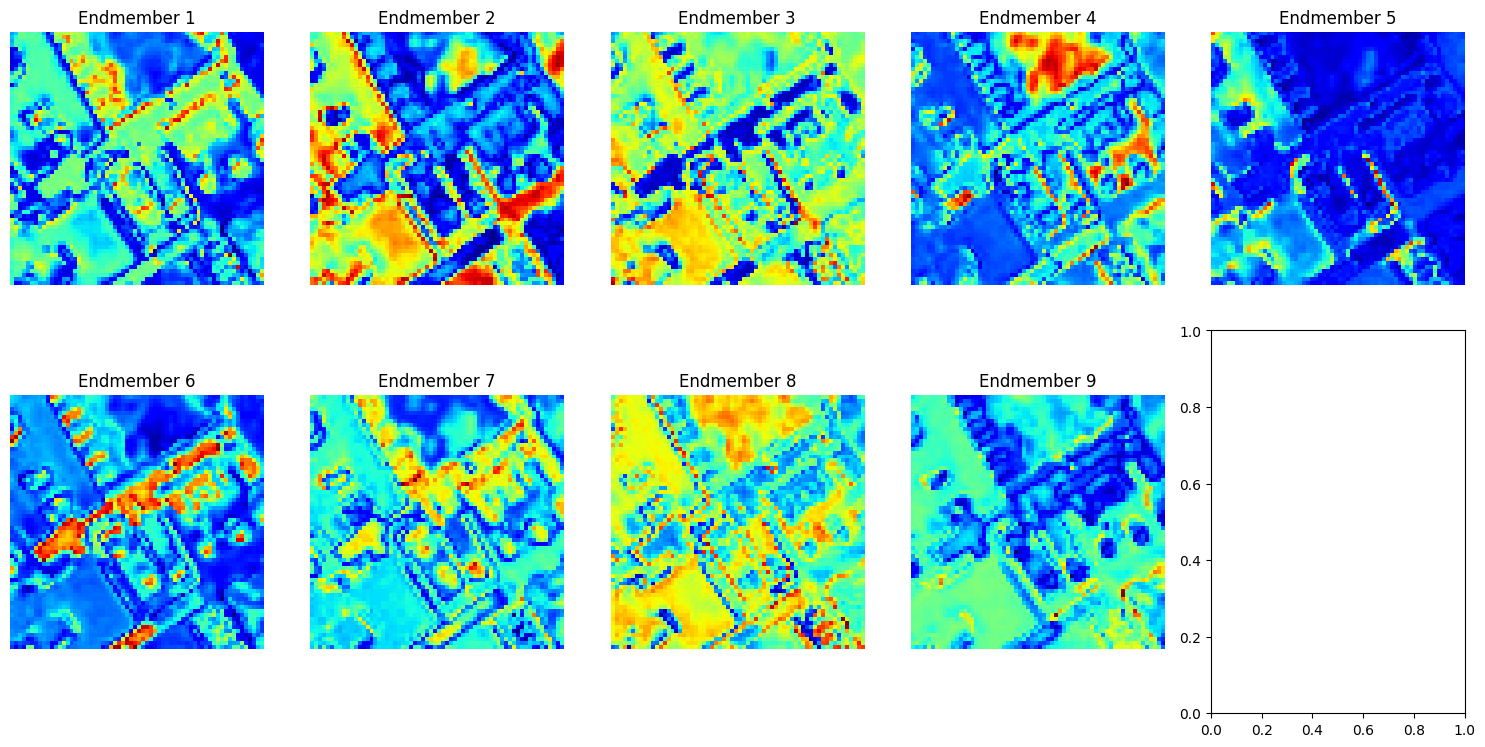

Top 5 most important bands: [96, 7, 57, 91, 78]
Faithfulness Score: 1.1218  (higher = causal bands matter more)
Conservation Score: 3.0091  (closer to 1.0 = better)


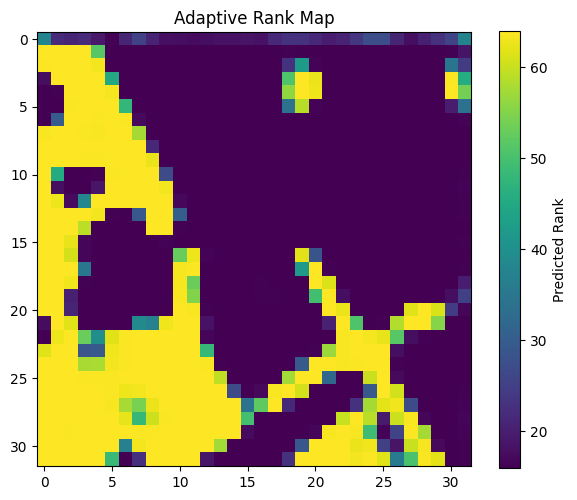

Rank map min/max: 16.0 / 64.0


In [72]:
def analyze_explainability(model, test_loader, device='cpu', sample_idx=0):
    model.eval()

    with torch.no_grad():
        for lr_imgs, hr_imgs in test_loader:
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)
            sample_lr = lr_imgs[sample_idx:sample_idx+1]
            sample_hr = hr_imgs[sample_idx:sample_idx+1]

            explainability = model.get_explainability(sample_lr)

            # Band importance
            band_importance = explainability['band_importance'].cpu().numpy().flatten()
            plt.figure(figsize=(12, 4))
            plt.bar(range(len(band_importance)), band_importance)
            plt.xlabel('Spectral Band')
            plt.ylabel('Importance Score')
            plt.title('Band Importance from Causal Graph')
            plt.tight_layout()
            plt.show()

            # Causal matrix — real pairwise structure via the causal graph's attention module
            cg = model.causal_graph
            B = sample_lr.shape[0]
            band_emb = cg.band_embeddings.unsqueeze(0).expand(B, -1, -1)          # (B, C, hidden)
            _, attn_weights = cg.causal_attention(band_emb, band_emb, band_emb)  # (B, C, C)
            pairwise_matrix = attn_weights.mean(dim=0).cpu().numpy()             # (C, C)

            plt.figure(figsize=(10, 8))
            plt.imshow(pairwise_matrix, cmap='hot', interpolation='nearest')
            plt.colorbar(label='Causal Strength')
            plt.xlabel('Target Band')
            plt.ylabel('Source Band')
            plt.title('Causal Relationship Matrix')
            plt.tight_layout()
            plt.show()

            # Abundance maps
            abundance_maps = explainability['abundance_maps'].cpu().numpy()[0]
            num_endmembers = abundance_maps.shape[0]
            fig, axs = plt.subplots(2, (num_endmembers + 1) // 2, figsize=(15, 8))
            axs = axs.flatten()
            for i in range(num_endmembers):
                axs[i].imshow(abundance_maps[i], cmap='jet')
                axs[i].set_title(f'Endmember {i+1}')
                axs[i].axis('off')
            plt.tight_layout()
            plt.show()

            # Faithfulness score
            t = torch.zeros(sample_lr.shape[0], dtype=torch.long, device=device)
            x_sr, _, causal_mat, _ = model.forward(sample_lr, t)

            # Get top-5 most important bands
            top_k_bands = band_importance.argsort()[-5:][::-1].tolist()
            print(f"Top 5 most important bands: {top_k_bands}")

            # Compute faithfulness manually
            with torch.no_grad():
                base_output, _, _, _ = model.forward(sample_lr, t)
                x_perturbed = sample_lr.clone()
                for band_idx in top_k_bands:
                    x_perturbed[:, band_idx, :, :] = 0.0
                perturbed_output, _, _, _ = model.forward(x_perturbed, t)

                error_base = torch.mean((base_output - sample_hr) ** 2).item()
                error_perturbed = torch.mean((perturbed_output - sample_hr) ** 2).item()
                faithfulness = (error_perturbed - error_base) / (error_base + 1e-8)
                print(f"Faithfulness Score: {faithfulness:.4f}  (higher = causal bands matter more)")

            # Conservation score
            with torch.no_grad():
                baseline = torch.zeros_like(sample_lr)
                t_base = torch.zeros(baseline.shape[0], dtype=torch.long, device=device)
                output_baseline, _, _, _ = model.forward(baseline, t_base)
                output_x, _, _, _ = model.forward(sample_lr, t)
                output_diff = (output_x - output_baseline).sum().item()
                input_sum = sample_lr.sum().item()
                conservation = output_diff / (input_sum + 1e-8)
                print(f"Conservation Score: {conservation:.4f}  (closer to 1.0 = better)")

            # Rank map visualization
            rank_map = explainability['rank_map'].cpu().numpy()[0, 0]
            plt.figure(figsize=(6, 5))
            plt.imshow(rank_map, cmap='viridis')
            plt.colorbar(label='Predicted Rank')
            plt.title('Adaptive Rank Map')
            plt.tight_layout()
            plt.show()
            print(f"Rank map min/max: {rank_map.min():.1f} / {rank_map.max():.1f}")

            break

print("Analyzing explainability...")
analyze_explainability(model, test_loader, device=device, sample_idx=0)

In [73]:
# Compute all final metrics on full test set
print("Computing final metrics on full test set...")
model.eval()

all_preds = []
all_gts = []

with torch.no_grad():
    for lr_imgs, hr_imgs in tqdm(test_loader, desc="Final Evaluation"):
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)
        t = torch.zeros(lr_imgs.shape[0], dtype=torch.long, device=device)
        x_sr, _, _, _ = model.forward(lr_imgs, t)
        all_preds.append(x_sr.cpu())
        all_gts.append(hr_imgs.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_gts   = torch.cat(all_gts,   dim=0)

final_metrics = ComprehensiveMetrics.compute_all_metrics(all_preds, all_gts, SCALE)

print("\n========== FINAL RESULTS ==========")
print(f"PSNR:  {final_metrics['PSNR']:.4f} dB")
print(f"SSIM:  {final_metrics['SSIM']:.4f}")
print(f"SAM:   {final_metrics['SAM']:.4f} degrees")
print(f"RMSE:  {final_metrics['RMSE']:.6f}")
print(f"ERGAS: {final_metrics['ERGAS']:.4f}")
print("====================================")

# Save final model
final_checkpoint_path = os.path.join(ckpt_dir, 'final_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_psnr': best_psnr,
    'final_metrics': final_metrics,
    'config': {
        'num_bands': NUM_BANDS,
        'latent_rank': LATENT_RANK,
        'num_endmembers': NUM_ENDMEMBERS,
        'max_rank': MAX_RANK,
        'min_rank': MIN_RANK,
        'num_timesteps': NUM_TIMESTEPS,
        'grid_size': GRID_SIZE
    }
}, final_checkpoint_path)

print(f"\nFinal model saved to: {final_checkpoint_path}")
print(f"Best PSNR achieved: {best_psnr:.4f}")

Computing final metrics on full test set...


Final Evaluation: 100%|██████████| 61/61 [00:03<00:00, 18.41it/s]



========== FINAL RESULTS ==========
PSNR:  34.0416 dB
SSIM:  0.9480
SAM:   3.1033 degrees
RMSE:  0.016444
ERGAS: 5.2549

Final model saved to: ./results/checkpoints_2026-07-04_16-17-22/final_model.pth
Best PSNR achieved: 34.0416
